# Phase 0 - visual sanity checks

Every cell below ends the same way: something becomes a **64x64 boolean mask**, and
that mask goes to `draw()`. Terms are never plotted directly - `render()` is the translator.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib

# this notebook lives in testing/, but `oracle` sits one level up.
# walk upward until we find the folder that contains it, then put that on the import path.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "oracle").is_dir())
sys.path.insert(0, str(ROOT))
print("project root:", ROOT)

import numpy as np
from pathlib import Path
import classiq
from oracle.mask import COORD_BITS, GRID_SIZE, TARGET, draw
from oracle.terms import Rect, Cube, Parity, HalfPlane,cover_mask, matches_target
from oracle.baseline import BASELINE_TERMS
from oracle.compile import build_main
from classiq import *
from oracle.measure import measurement
from oracle.verify import verify
from oracle.evaluate import evaluate
from oracle.terms import fingerprint
from oracle.measure import build_settings, cache_key
from oracle.proxy import _examine_bits

project root: /mnt/c/Users/seanz/Documents/Quantum/Classiq Challenge


In [2]:
classiq.authenticate()

/home/aoeuhtns/miniconda/envs/quantum/lib/python3.13/site-packages/classiq/_internals/authentication/token_manager.py:116: UserWarning: Device is already registered.
Generating a new refresh token should only be done if the current refresh token is compromised.
To do so, set the overwrite parameter to true
  warnings.warn(


In [4]:
print(_examine_bits(63, upper=True))
print(_examine_bits(0, upper=False))
print(_examine_bits(31, upper=True))
print(_examine_bits(20, upper=True))

0
0
1
6


In [60]:
m, v, run_id = evaluate(BASELINE_TERMS, seed=7)

Submitting state-vector job to simulator
Submitting state-vector job to simulator
Submitting state-vector job to simulator


In [61]:
print(m.depth, v.depth, v.ok)

5267 5267 True


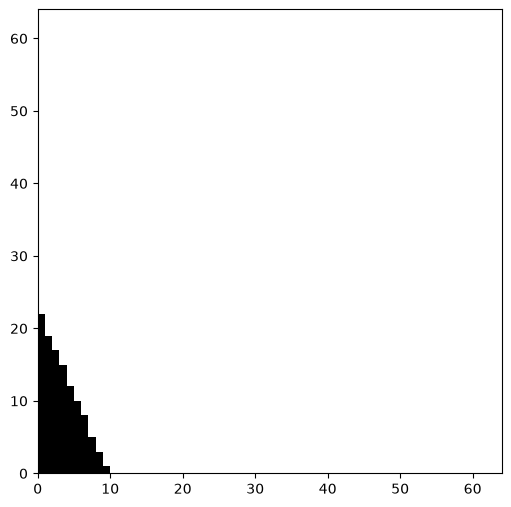

In [47]:
draw(HalfPlane(7, 3, 63).render())

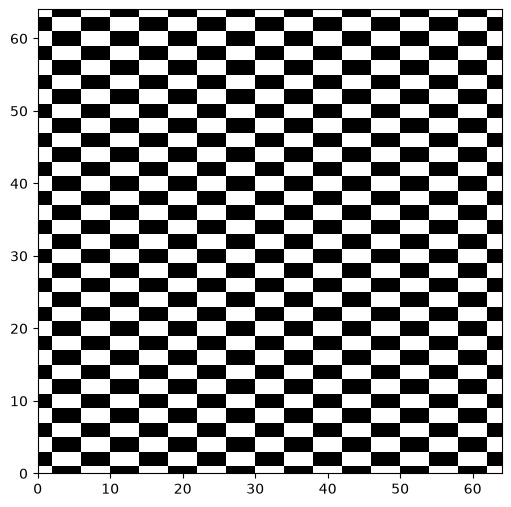

In [39]:
draw(Parity.fix(x=[1,2], y=[0,1]).render())